## Wind speed analysis

In [193]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import pandas as pd
from scipy.stats import percentileofscore

In [194]:
wind_fina=xr.open_dataset('data/wind_fina_extended_bigger.nc')
wind_alfred=xr.open_dataset('data/wind_alfred_extended_bigger.nc')
wind_baseline_first=xr.open_dataset('data/wind_baseline_extended_bigger_1.nc')
wind_baseline_second=xr.open_dataset('data/wind_baseline_extended_bigger_2.nc')
wind_baseline_third=xr.open_dataset('data/wind_baseline_extended_bigger_3.nc')

## Exclude cyclone periods

In [195]:
exclude_periods=[('2020-02-04', '2020-02-14'), ('2020-03-14', '2020-03-15'), ('2021-01-16', '2021-01-19'), ('2021-01-24', '2021-02-01'), ('2021-02-27', '2021-03-05'), ('2021-12-09', '2021-12-15'), ('2022-02-07', '2022-02-12')]

In [196]:
#exclude dates if in exclude_periods

def exclude_periods_from_ds(ds, exclude_periods):
    time = ds['time']

    # start with all True (keep everything)
    keep_mask = xr.ones_like(time, dtype=bool)

    for start, end in exclude_periods:
        start = np.datetime64(start)
        end = np.datetime64(end)

        keep_mask = keep_mask & ~((time >= start) & (time <= end))

    return ds.sel(time=keep_mask)

In [197]:
wind_baseline_first_clean  = exclude_periods_from_ds(
    wind_baseline_first, exclude_periods
)

wind_baseline_second_clean = exclude_periods_from_ds(
    wind_baseline_second, exclude_periods
)

wind_baseline_third_clean  = exclude_periods_from_ds(
    wind_baseline_third, exclude_periods
)


## Compute wind speeds

In [198]:
u_fina=wind_fina['eastward_wind']
v_fina=wind_fina['northward_wind']

u_alfred=wind_alfred['eastward_wind']
v_alfred=wind_alfred['northward_wind']

u_baseline_first=wind_baseline_first['eastward_wind']
v_baseline_first=wind_baseline_first['northward_wind']

u_baseline_second=wind_baseline_second['eastward_wind']
v_baseline_second=wind_baseline_second['northward_wind']

u_baseline_third=wind_baseline_third['eastward_wind']
v_baseline_third=wind_baseline_third['northward_wind']


wind_speed_fina=np.sqrt(u_fina**2+v_fina**2)
#print(wind_speed_fina) #data array with 3 dimensions (time, latitude, longitude). each subarray gives the wind speeds at different longitudes for one fixed latitude
wind_speed_alfred=np.sqrt(u_alfred**2+v_alfred**2)
wind_speed_baseline_first=np.sqrt(u_baseline_first**2+v_baseline_first**2)
wind_speed_baseline_second=np.sqrt(u_baseline_second**2+v_baseline_second**2)
wind_speed_baseline_third=np.sqrt(u_baseline_third**2+v_baseline_third**2)

In [199]:
#fixes the dimensions of the data array to be only time, by averaging over the spatial dimensions (latitude and longitude)
wind_ts_fina = wind_speed_fina.mean(dim=("latitude", "longitude"))
wind_ts_fina = wind_ts_fina.sel(time=slice("2011-12-01", "2012-01-31")) #selects only the time period of interest (during cyclone Fina)
print("Max wind speed during cyclone Fina:", wind_ts_fina.max().values, "m/s")

wind_ts_alfred = wind_speed_alfred.mean(dim=("latitude", "longitude"))
wind_ts_alfred = wind_ts_alfred.sel(time=slice("2025-02-01", "2025-03-31"))
print("Max wind speed during cyclone Alfred:", wind_ts_alfred.max().values, "m/s")

wind_ts_baseline_first = wind_speed_baseline_first.mean(dim=("latitude", "longitude"))
wind_ts_baseline_second = wind_speed_baseline_second.mean(dim=("latitude", "longitude"))
wind_ts_baseline_third = wind_speed_baseline_third.mean(dim=("latitude", "longitude"))


Max wind speed during cyclone Fina: 9.180693626403809 m/s
Max wind speed during cyclone Alfred: 11.67247486114502 m/s


## Average the baseline period

In [200]:
baseline_ts_list = [
    wind_ts_baseline_first,
    wind_ts_baseline_second,
    wind_ts_baseline_third,
]

def add_season_day(da):
    time = da.time.to_index()

    # Define November 1 of the relevant season
    season_start = time.map(
        lambda t: pd.Timestamp(t.year if t.month >= 11 else t.year - 1, 11, 1)
    )

    season_day = (time - season_start).days

    return da.assign_coords(season_day=("time", season_day))

baseline_seasonal_wind = [add_season_day(ts) for ts in baseline_ts_list]

baseline_all = xr.concat(baseline_seasonal_wind, dim="season")

baseline_mean_wind = (
    baseline_all
    .groupby("season_day")
    .mean(skipna=True)
)

wind_baseline_speed = xr.concat(    [        wind_speed_baseline_first,        wind_speed_baseline_second,        wind_speed_baseline_third,    ],    dim="time",)
#print(baseline_mean_wind)
print("Mean wind speed during baseline period:", baseline_mean_wind.mean().values, "m/s")

Mean wind speed during baseline period: 6.206684187838905 m/s


## Plots

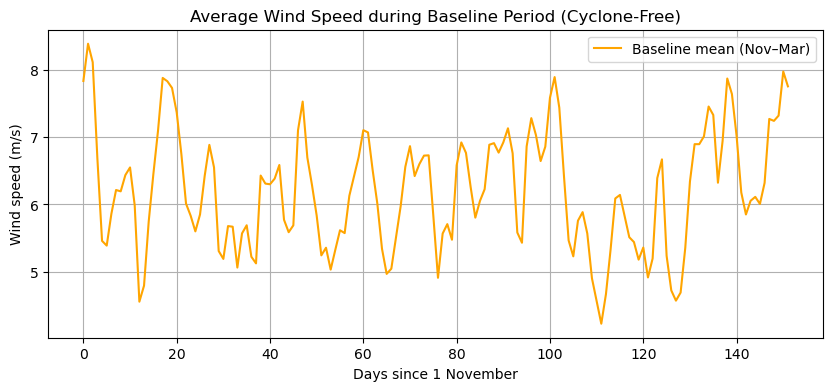

In [201]:

plt.figure(figsize=(10, 4))
plt.plot(
    baseline_mean_wind.season_day,
    baseline_mean_wind,
    label="Baseline mean (Nov–Mar)",
    color="orange"
)

plt.xlabel("Days since 1 November")
plt.ylabel("Wind speed (m/s)")
plt.title("Average Wind Speed during Baseline Period (Cyclone-Free)")
plt.grid(True)
plt.legend()
#save plot
#plt.savefig("plots/baseline_wind_speed.png", dpi=300, bbox_inches="tight")
plt.show()


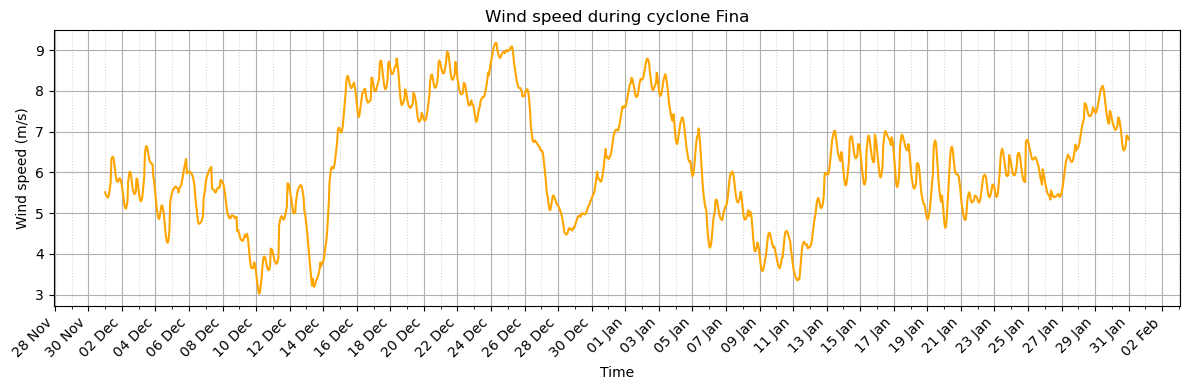

In [202]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_fina.plot(ax=ax, color='orange')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Fina")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
#plt.savefig("plots/fina_wind_speed.png", dpi=300, bbox_inches="tight")
plt.show()



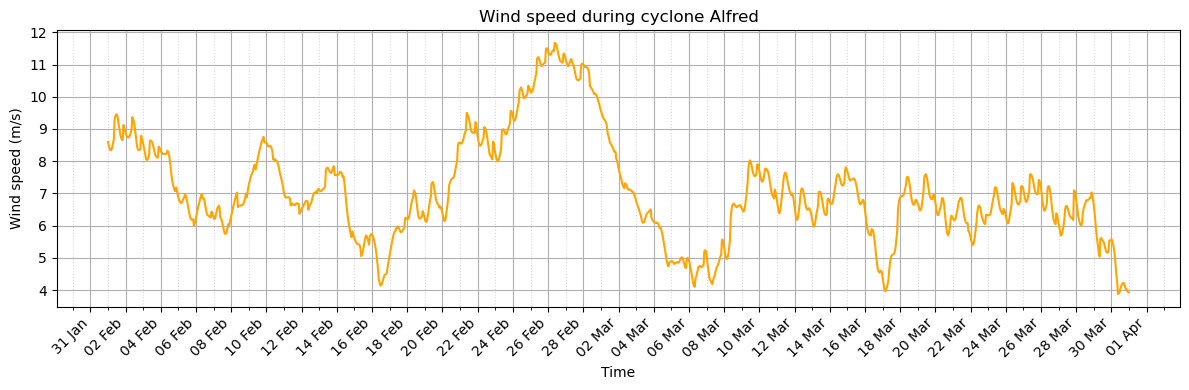

In [203]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_alfred.plot(ax=ax, color='orange')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Alfred")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
#plt.savefig("plots/alfred_wind_speed.png", dpi=300, bbox_inches="tight")
plt.show()

## Wave analysis

In [204]:
wave_fina=xr.open_dataset('data/wave_fina_extended_bigger.nc')
wave_alfred=xr.open_dataset('data/wave_alfred_extended_bigger.nc')
wave_baseline_first=xr.open_dataset('data/wave_baseline_extended_bigger_1.nc') 
wave_baseline_second=xr.open_dataset('data/wave_baseline_extended_bigger_2.nc')
wave_baseline_third=xr.open_dataset('data/wave_baseline_extended_bigger_3.nc')
#list(wave_baseline_third.variables)

## exclude cyclone periods from baseline

In [205]:
wave_baseline_clean_first= exclude_periods_from_ds(
    wave_baseline_first, exclude_periods
)
wave_baseline_clean_second= exclude_periods_from_ds(
    wave_baseline_second, exclude_periods
)
wave_baseline_clean_third= exclude_periods_from_ds(
    wave_baseline_third, exclude_periods
)

## average over baseline period

In [206]:
height_fina=wave_fina['VHM0']
height_alfred=wave_alfred['VHM0']
height_baseline_first=wave_baseline_clean_first['VHM0']
height_baseline_second=wave_baseline_clean_second['VHM0']
height_baseline_third=wave_baseline_clean_third['VHM0']
print(height_baseline_first)

<xarray.DataArray 'VHM0' (time: 1119, latitude: 70, longitude: 75)> Size: 23MB
[5874750 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 9kB 2019-11-01 ... 2020-03-31
  * latitude   (latitude) float32 280B -26.8 -26.6 -26.4 ... -13.4 -13.2 -13.0
  * longitude  (longitude) float32 300B 150.2 150.4 150.6 ... 164.6 164.8 165.0
Attributes:
    units:             m
    standard_name:     sea_surface_wave_significant_height
    long_name:         Spectral significant wave height (Hm0)
    WMO_code:          100
    cell_methods:      time:point area:mean
    type_of_analysis:  spectral analysis


In [207]:
waveheight_baseline_list = [
    height_baseline_first.mean(dim=("latitude", "longitude")),
    height_baseline_second.mean(dim=("latitude", "longitude")),
    height_baseline_third.mean(dim=("latitude", "longitude")),
]

baseline_seasonal_wave = [add_season_day(ts) for ts in waveheight_baseline_list]

baseline_all_wave = xr.concat(baseline_seasonal_wave, dim="season")

baseline_mean_wave = (
    baseline_all_wave
    .groupby("season_day")
    .mean(skipna=True)
)

## plots

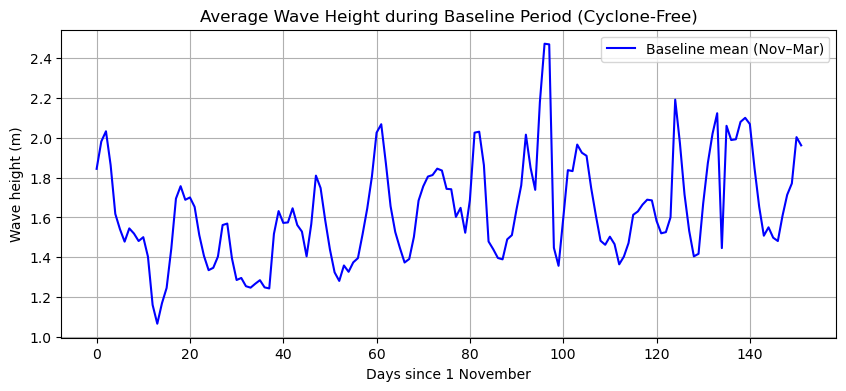

In [208]:
plt.figure(figsize=(10, 4))
plt.plot(
    baseline_mean_wave.season_day,
    baseline_mean_wave,
    label="Baseline mean (Nov–Mar)",
    color="blue"
)

plt.xlabel("Days since 1 November")
plt.ylabel("Wave height (m)")
plt.title("Average Wave Height during Baseline Period (Cyclone-Free)")
plt.grid(True)
plt.legend()
#plt.savefig("plots/baseline_wave_height.png", dpi=300, bbox_inches="tight")
plt.show()

In [209]:
wave_ts_fina = height_fina.mean(dim=("latitude", "longitude"))

print("Max wave height during cyclone Fina:", wave_ts_fina.max().values, "m")
wave_ts_alfred = height_alfred.mean(dim=("latitude", "longitude"))
print("Max wave height during cyclone Alfred:", wave_ts_alfred.max().values, "m")

print("Mean wave height during baseline period:", baseline_mean_wave.mean().values, "m")


Max wave height during cyclone Fina: 2.759697437286377 m
Max wave height during cyclone Alfred: 3.742614984512329 m
Mean wave height during baseline period: 1.6325748954948627 m


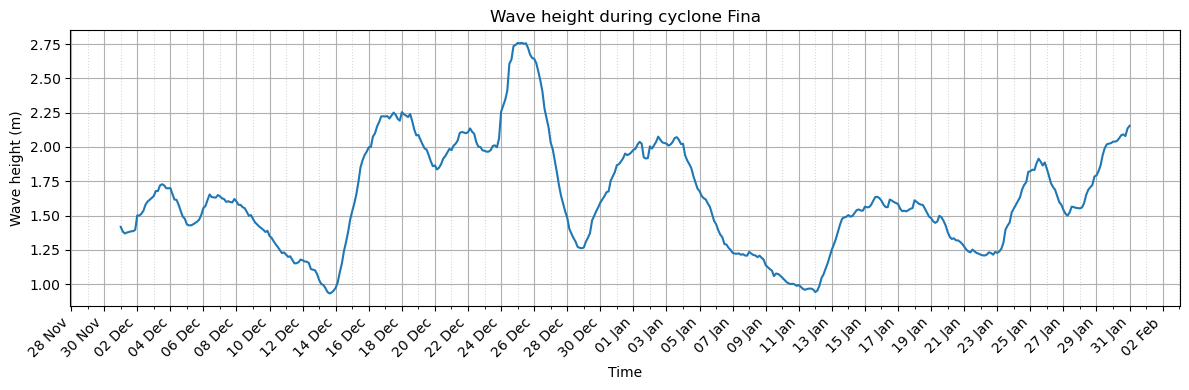

In [210]:
fig, ax = plt.subplots(figsize=(12, 4))

wave_ts_fina.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wave height during cyclone Fina")
ax.set_ylabel("Wave height (m)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
#plt.savefig("plots/fina_wave_height.png", dpi=300, bbox_inches="tight")
plt.show()

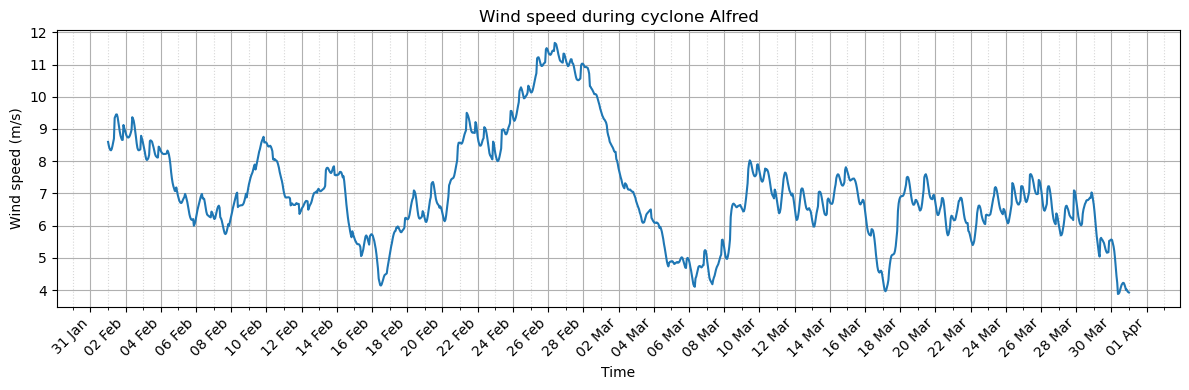

In [211]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_alfred.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Alfred")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
#plt.savefig("plots/alfred_wave_height.png", dpi=300, bbox_inches="tight")
plt.show()

## Combined analysis

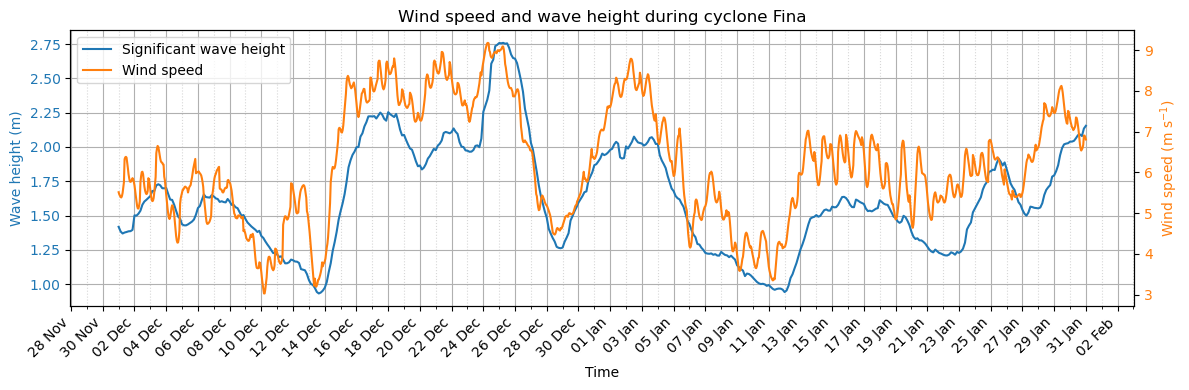

In [212]:
#Fina
fig, ax_wave = plt.subplots(figsize=(12, 4))

# wave height (left y-axis)
wave_line, = wave_ts_fina.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = wind_ts_fina.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax_wave.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_wave.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during cyclone Fina")
ax_wave.set_xlabel("Time")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="upper left")

plt.tight_layout()
#plt.savefig("plots/fina_combined.png", dpi=300, bbox_inches="tight")
plt.show()


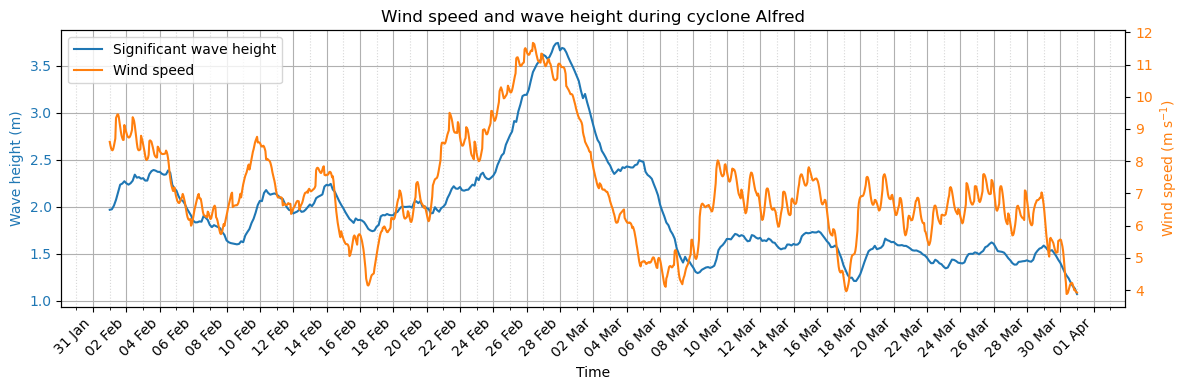

In [213]:
#Alfred
fig, ax_wave = plt.subplots(figsize=(12, 4))

# wave height (left y-axis)
wave_line, = wave_ts_alfred.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = wind_ts_alfred.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax_wave.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_wave.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during cyclone Alfred")
ax_wave.set_xlabel("Time")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="upper left")

plt.tight_layout()
#plt.savefig("plots/alfred_combined.png", dpi=300, bbox_inches="tight")
plt.show()


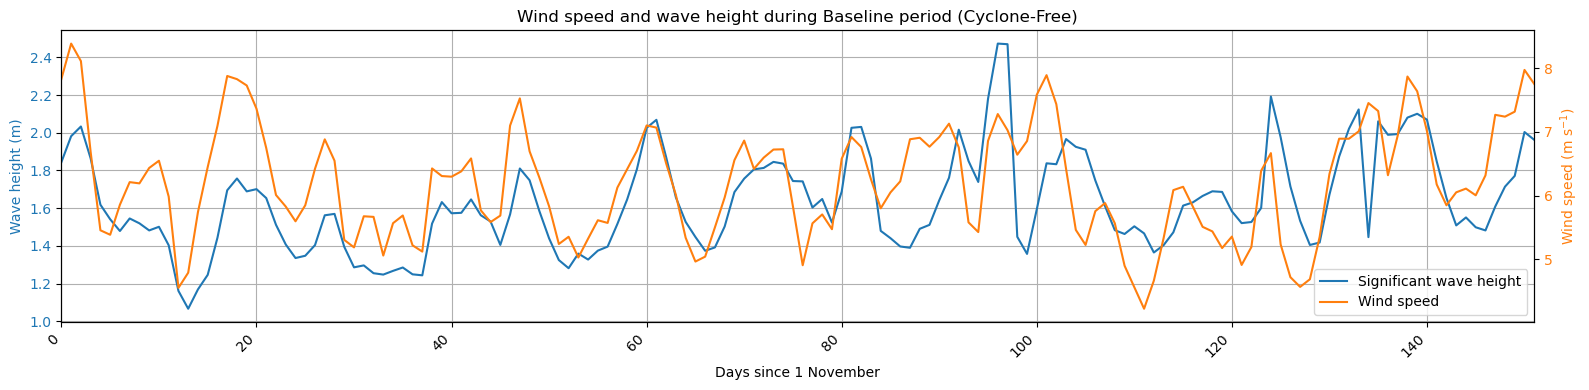

In [214]:
#baseline
fig, ax_wave = plt.subplots(figsize=(16, 4))

# wave height (left y-axis)
wave_line, = baseline_mean_wave.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = baseline_mean_wind.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.set_xlim(0, 151)
ax_wave.set_xlabel("Days since 1 November")

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during Baseline period (Cyclone-Free)")
ax_wave.set_xlabel("Days since 1 November")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="lower right")

plt.tight_layout()
#plt.savefig("plots/baseline_combined.png", dpi=300, bbox_inches="tight")
plt.show()



## Statistics

In [215]:
import numpy as np
import xarray as xr
from scipy.stats import ttest_ind

In [216]:
#convert xarray.DataArray to pandas DateTimeIndex
def add_season_day(da):
    time = da.time.to_index()
    #defines start of sommer season, if month is november or later, season starts on november 1 of the same year, otherwise on november 1 of the previous year
    season_start = time.map(
        lambda t: pd.Timestamp(t.year if t.month >= 11 else t.year - 1, 11, 1)
    )
    #compute how many days since season start (november 1)
    season_day = (time - season_start).days
    return da.assign_coords(season_day=("time", season_day))


def cyclone_peak_vs_baseline_seasonal_day(
    cyclone_da,
    baseline_da,
    peak_date,
    time_window=0, #how many days before and after the peak date, 0 means just the peak date itself
):
    """
    Cyclone peak vs baseline distribution for the same seasonal day.
    """

    # add seasonal day to baseline, so that it can compare the cyclone peak to a corresponding season and not just whole baseline
    baseline_da = add_season_day(baseline_da)

    # spatial cyclone peak 
    cyclone_peak = cyclone_da.sel(
        time=slice(
            np.datetime64(peak_date) - np.timedelta64(time_window, "D"),
            np.datetime64(peak_date) + np.timedelta64(time_window, "D"),
        )
    ).mean("time")

    # take seasonal day of the peak date
    peak_sd = np.unique(
        add_season_day(cyclone_da.sel(time=peak_date)).season_day.values
    )
    #if multiple days
    if len(peak_sd) != 1:
        raise ValueError(
            "Peak date spans multiple seasonal days — check time axis"
        )

    peak_sd = peak_sd[0] #single integer value representing the seasonal day of the cyclone peak, days since novembe 1

    # baseline for the same seasonal day (all years, all grid points)
    baseline_sd = baseline_da.where(
        baseline_da.season_day == peak_sd,
        drop=True
    )

    # --- baseline statistics ---
    baseline_mean = baseline_sd.mean("time")
    baseline_std  = baseline_sd.std("time")

    # --- align grids for pointwise operations ---
    baseline_sd, cyclone_peak = xr.align(
        baseline_sd,
        cyclone_peak,
        join="inner"
     )

    anomaly = cyclone_peak - baseline_mean
    zscore = anomaly / baseline_std

    percentile = xr.apply_ufunc(
        percentileofscore,
        baseline_sd,
        cyclone_peak,
        vectorize=True,
        input_core_dims=[["time"], []],
        output_dtypes=[float],
    )


    return xr.Dataset(
    {
        "cyclone_value": cyclone_peak,
        "baseline_mean": baseline_mean,
        "anomaly": anomaly,
        "zscore": zscore,
        "percentile": percentile,
        "season_day": xr.DataArray(peak_sd),
    }
)

Wind

In [217]:
alfred_wind_peak = cyclone_peak_vs_baseline_seasonal_day(
    cyclone_da=wind_speed_alfred,
    baseline_da=wind_baseline_speed,
    peak_date="2025-02-28",
    time_window=0,
)

fina_wind_peak = cyclone_peak_vs_baseline_seasonal_day(
    cyclone_da=wind_speed_fina,
    baseline_da=wind_baseline_speed,
    peak_date="2011-12-21", 
    time_window=1,
)

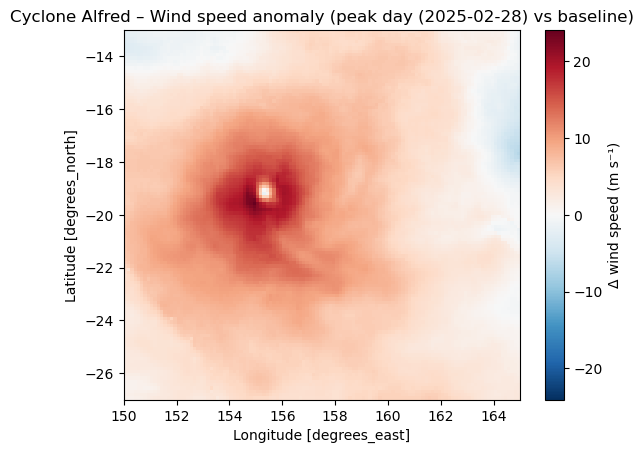

In [218]:
alfred_wind_peak["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wind speed (m s⁻¹)"},
)
plt.title("Cyclone Alfred – Wind speed anomaly (peak day (2025-02-28) vs baseline)")
plt.show()

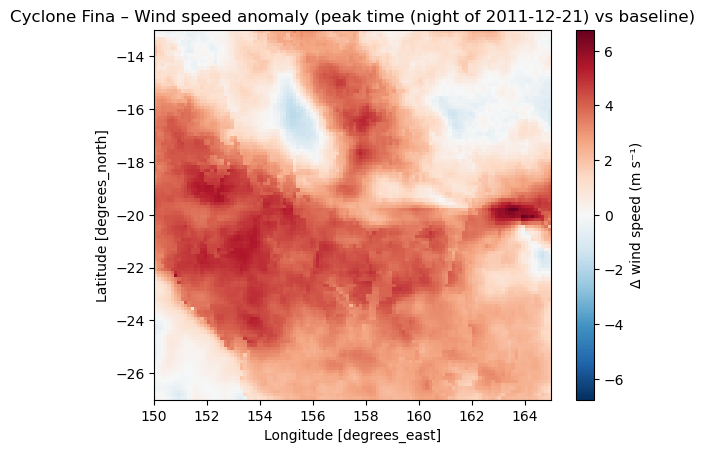

In [219]:
fina_wind_peak["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wind speed (m s⁻¹)"},
)
plt.title("Cyclone Fina – Wind speed anomaly (peak time (night of 2011-12-21) vs baseline)")
plt.show()

Wave

In [220]:
wave_baseline = xr.concat(
    [
        height_baseline_first,
        height_baseline_second,
        height_baseline_third,
    ],
    dim="time",
)


In [221]:
alfred_wave_peak = cyclone_peak_vs_baseline_seasonal_day(
    cyclone_da=height_alfred,
    baseline_da=wave_baseline,
    peak_date="2025-02-28",
    time_window=0,
)

fina_wave_peak = cyclone_peak_vs_baseline_seasonal_day(
    cyclone_da=height_fina,
    baseline_da=wave_baseline,
    peak_date="2011-12-21",   # adjust if needed
    time_window=1,
)


In [222]:
#longitudes and latitudes of fina wave peak
print("Fina wave peak longitude:", fina_wave_peak.cyclone_value.longitude.values)
print("Fina wave peak latitude:", fina_wave_peak.cyclone_value.latitude.values)


Fina wave peak longitude: [150.19998 150.4     150.59999 150.79999 150.99998 151.19998 151.4
 151.59999 151.79999 151.99998 152.19998 152.4     152.59999 152.79999
 152.99998 153.19998 153.4     153.59999 153.79999 153.99998 154.19998
 154.4     154.59999 154.79999 154.99998 155.19998 155.4     155.59999
 155.79999 155.99998 156.19998 156.4     156.59999 156.79999 156.99998
 157.19998 157.4     157.59999 157.79999 157.99998 158.19998 158.4
 158.59999 158.79999 158.99998 159.19998 159.4     159.59999 159.79999
 159.99998 160.19998 160.4     160.59999 160.79999 160.99998 161.19998
 161.4     161.59999 161.79999 161.99998 162.19998 162.4     162.59999
 162.79999 162.99998 163.19998 163.4     163.59999 163.79999 163.99998
 164.19998 164.4     164.59999 164.79999 164.99998]
Fina wave peak latitude: [-26.800001 -26.6      -26.400002 -26.2      -26.       -25.800001
 -25.6      -25.400002 -25.2      -25.       -24.800001 -24.6
 -24.400002 -24.2      -24.       -23.800001 -23.6      -23.400002

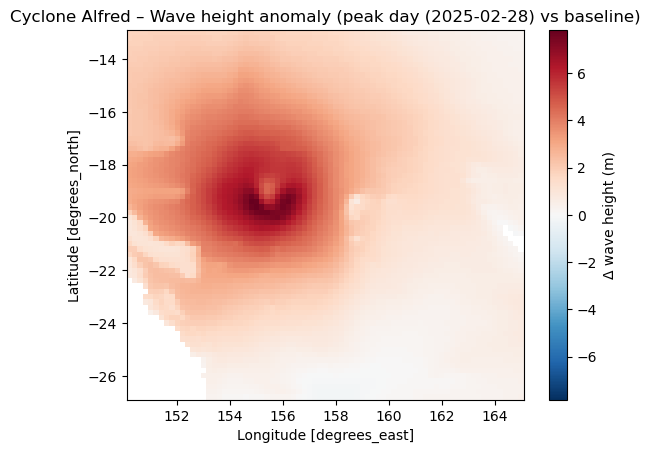

In [223]:
alfred_wave_peak["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wave height (m)"},
)
plt.title("Cyclone Alfred – Wave height anomaly (peak day (2025-02-28) vs baseline)")
plt.show()

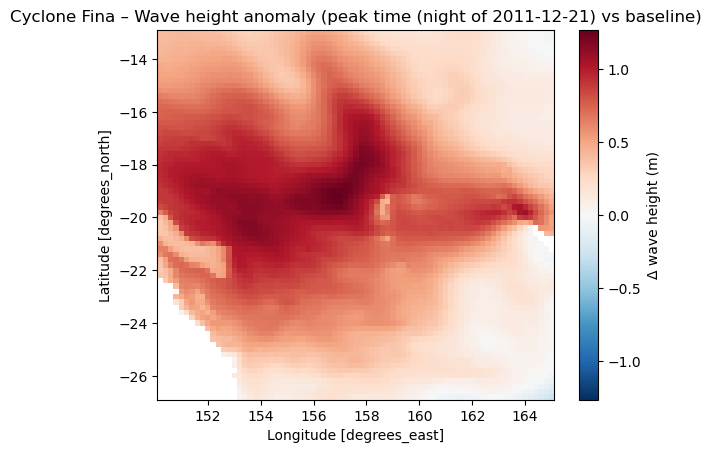

In [224]:
fina_wave_peak["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wave height (m)"},
)
plt.title("Cyclone Fina – Wave height anomaly (peak time (night of 2011-12-21) vs baseline)")
plt.show()

time series of anomalies

In [225]:
def baseline_timeseries_for_event(event_ts, baseline_seasonal):
    """
    Map each time in event_ts to the corresponding seasonal-day baseline.
    """
    event_sd = add_season_day(event_ts).season_day
    baseline_for_event = baseline_seasonal.sel(
        season_day=event_sd
    ).values
    return xr.DataArray(
        baseline_for_event,
        coords=event_ts.coords,
        dims=event_ts.dims,
    )

In [226]:
def to_days_since_start(da):
    """
    Convert a DataArray with a time coordinate
    to days since the first time step.
    """
    days = (da.time - da.time[0]) / np.timedelta64(1, "D")
    return da.assign_coords(days_since_start=days)

In [227]:
# wind
baseline_wind_alfred_ts = baseline_timeseries_for_event(
    wind_ts_alfred, baseline_mean_wind
)
baseline_wind_fina_ts = baseline_timeseries_for_event(
    wind_ts_fina, baseline_mean_wind
)

wind_anom_alfred_ts = wind_ts_alfred - baseline_wind_alfred_ts
wind_anom_fina_ts   = wind_ts_fina   - baseline_wind_fina_ts


In [228]:
wind_anom_alfred_rel = to_days_since_start(wind_anom_alfred_ts)
wind_anom_fina_rel   = to_days_since_start(wind_anom_fina_ts)

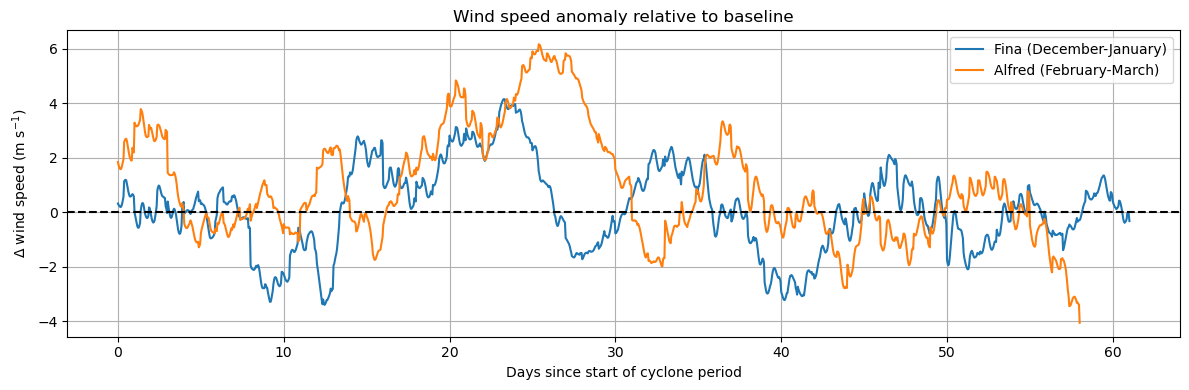

In [229]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wind_anom_fina_rel.days_since_start,
    wind_anom_fina_rel,
    label="Fina (December-January)",
    color="tab:blue",
)

ax.plot(
    wind_anom_alfred_rel.days_since_start,
    wind_anom_alfred_rel,
    label="Alfred (February-March)",
    color="tab:orange",
)

ax.axhline(0, color="black", linestyle="--")

ax.set_title("Wind speed anomaly relative to baseline")
ax.set_xlabel("Days since start of cyclone period")
ax.set_ylabel("Δ wind speed (m s$^{-1}$)")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [230]:
# wave
baseline_wave_alfred_ts = baseline_timeseries_for_event(
    wave_ts_alfred, baseline_mean_wave
)
baseline_wave_fina_ts = baseline_timeseries_for_event(
    wave_ts_fina, baseline_mean_wave
)

wave_anom_alfred_ts = wave_ts_alfred - baseline_wave_alfred_ts
wave_anom_fina_ts   = wave_ts_fina   - baseline_wave_fina_ts

In [231]:
wave_anom_alfred_rel = to_days_since_start(wave_anom_alfred_ts)
wave_anom_fina_rel   = to_days_since_start(wave_anom_fina_ts)

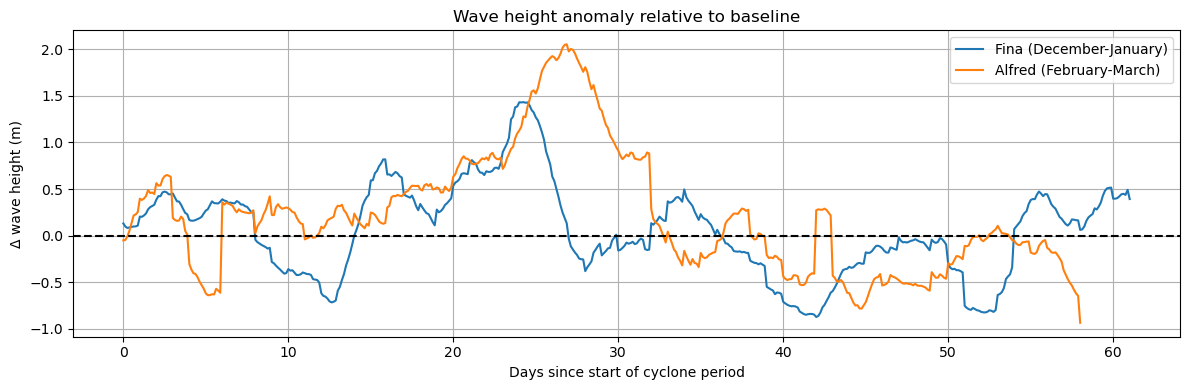

In [232]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wave_anom_fina_rel.days_since_start,
    wave_anom_fina_rel,
    label="Fina (December-January)",
    color="tab:blue",
)

ax.plot(
    wave_anom_alfred_rel.days_since_start,
    wave_anom_alfred_rel,
    label="Alfred (February-March)",
    color="tab:orange",
)

ax.axhline(0, color="black", linestyle="--")

ax.set_title("Wave height anomaly relative to baseline")
ax.set_xlabel("Days since start of cyclone period")
ax.set_ylabel("Δ wave height (m)")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## One sample T-test

mark peak areas in plots

In [233]:
lat_min = -19.5
lat_max = -18.5
lon_min = 155
lon_max = 156

In [234]:
def draw_focus_box(ax, lon_min, lon_max, lat_min, lat_max):
    """
    Draw a black rectangle on a map axis.
    """
    ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        color="black",
        linewidth=2,
    )

In [235]:
def three_day_mean(da, center_date):
    """
    Compute a 3‑day mean centred on center_date.
    """
    return da.sel(
        time=slice(
            np.datetime64(center_date) - np.timedelta64(1, "D"),
            np.datetime64(center_date) + np.timedelta64(1, "D"),
        )
    ).mean("time")


In [236]:
def add_season_day(da):
    time = da.time.to_index()
    season_start = time.map(
        lambda t: pd.Timestamp(t.year if t.month >= 11 else t.year - 1, 11, 1)
    )
    season_day = (time - season_start).days
    return da.assign_coords(season_day=("time", season_day))

In [237]:
from scipy.stats import ttest_1samp

def cyclone_peak_3day_onesample_ttest(
    cyclone_da,
    baseline_das,     # list of baseline datasets (one per summer)
    peak_date,
    alpha=0.05,
):
    """
    One‑sample t‑test comparing cyclone 3‑day mean
    against baseline 3‑day means (one per summer).
    """

    # --- cyclone 3‑day mean ---
    cyclone_peak = three_day_mean(cyclone_da, peak_date)

    # --- baseline 3‑day means (one per summer) ---
    baseline_means = []

    for bda in baseline_das:
        bda = add_season_day(bda)

        peak_sd = np.unique(
            add_season_day(cyclone_da.sel(time=peak_date))
            .season_day
            .values
        )[0]

        # select same seasonal day ±1 day
        baseline_window = bda.where(
            np.abs(bda.season_day - peak_sd) <= 1,
            drop=True
        )

        baseline_means.append(baseline_window.mean("time"))

    # stack as "sample" dimension
    baseline_stack = xr.concat(baseline_means, dim="sample")

    # ensure identical grids
    baseline_stack, cyclone_peak = xr.align(
        baseline_stack, cyclone_peak, join="inner"
    )

    # --- one‑sample t‑test ---
    tstat, pval = xr.apply_ufunc(
        ttest_1samp,
        baseline_stack,
        cyclone_peak,
        input_core_dims=[["sample"], []],
        output_core_dims=[[], []],
        kwargs={"nan_policy": "omit"},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

    # --- anomaly ---
    anomaly = cyclone_peak - baseline_stack.mean("sample")

    return xr.Dataset(
        {
            "anomaly": anomaly,
            "t_stat": tstat,
            "p_value": pval,
            "significant": pval < alpha,
        }
    )

In [238]:
alfred_wind_ttest = cyclone_peak_3day_onesample_ttest(
    cyclone_da=wind_speed_alfred,
    baseline_das=[
        wind_speed_baseline_first,
        wind_speed_baseline_second,
        wind_speed_baseline_third,
    ],
    peak_date="2025-02-28",
)

In [239]:
fina_wind_ttest = cyclone_peak_3day_onesample_ttest(
    cyclone_da=wind_speed_fina,
    baseline_das=[
        wind_speed_baseline_first,
        wind_speed_baseline_second,
        wind_speed_baseline_third,
    ],
    peak_date="2011-12-21",
)

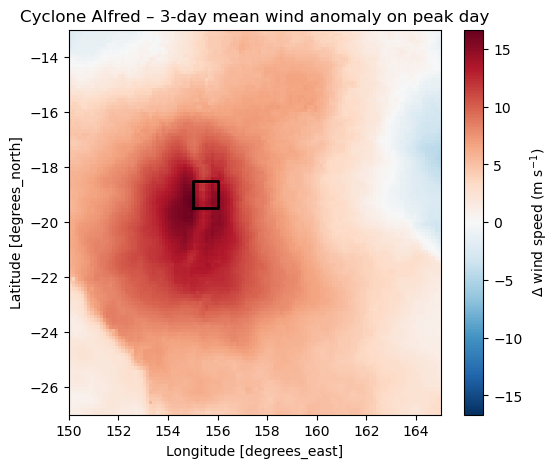

In [240]:
fig, ax = plt.subplots(figsize=(6, 5))

alfred_wind_ttest["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wind speed (m s$^{-1}$)"},
)

draw_focus_box(ax, 155, 156, -19.5, -18.5)

plt.title("Cyclone Alfred – 3‑day mean wind anomaly on peak day")
#save plot
plt.savefig("plots/new anomaly plots with box/alfred_wind_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()


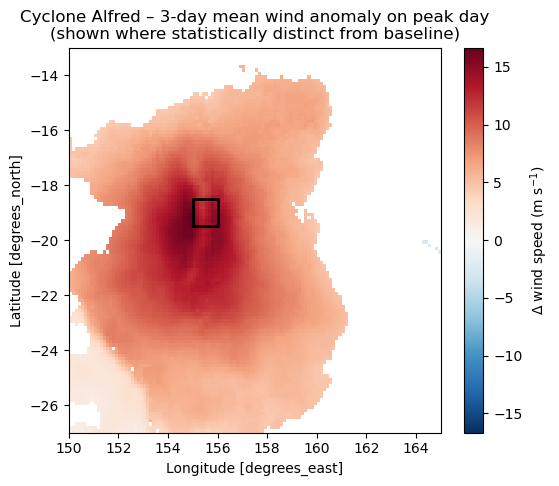

In [241]:

masked_anomaly_alfred = alfred_wind_ttest["anomaly"].where(
    alfred_wind_ttest["significant"]
)
fig, ax = plt.subplots(figsize=(6, 5))
masked_anomaly_alfred.plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wind speed (m s$^{-1}$)"},
)
draw_focus_box(ax, 155, 156, -19.5, -18.5)
plt.title("Cyclone Alfred – 3‑day mean wind anomaly on peak day\n(shown where statistically distinct from baseline)")
plt.savefig("plots/new anomaly plots with box/alfred_wind_anomaly_significant.png", dpi=300, bbox_inches="tight")
plt.show()

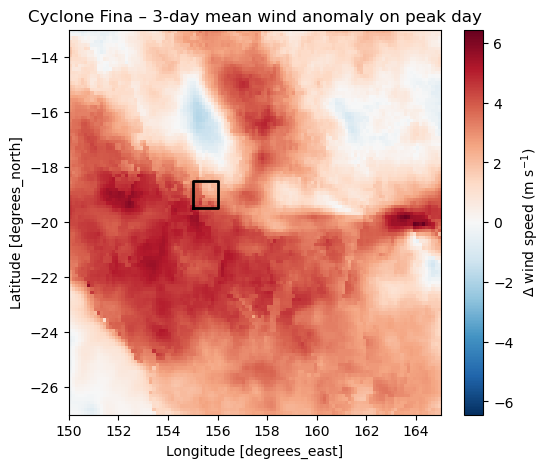

In [242]:
fig, ax = plt.subplots(figsize=(6, 5))
fina_wind_ttest["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wind speed (m s$^{-1}$)"},
)
draw_focus_box(ax, 155, 156, -19.5, -18.5)
plt.title("Cyclone Fina – 3‑day mean wind anomaly on peak day")
plt.savefig("plots/new anomaly plots with box/fina_wind_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()


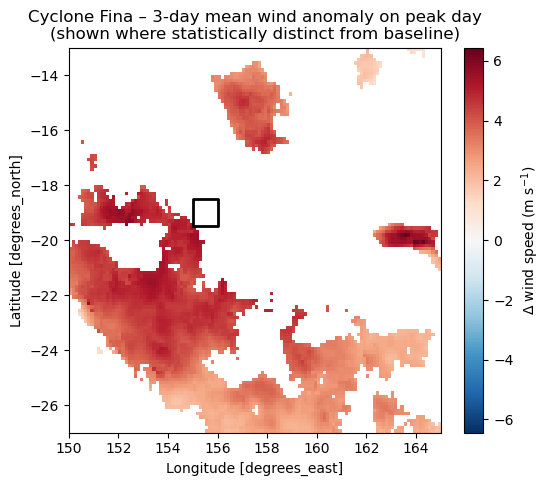

In [243]:
masked_anomaly_fina = fina_wind_ttest["anomaly"].where(
    fina_wind_ttest["significant"]
)
fig, ax = plt.subplots(figsize=(6, 5))
masked_anomaly_fina.plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wind speed (m s$^{-1}$)"},
)
draw_focus_box(ax, 155, 156, -19.5, -18.5)
plt.title("Cyclone Fina – 3‑day mean wind anomaly on peak day\n(shown where statistically distinct from baseline)")
plt.savefig("plots/new anomaly plots with box/fina_wind_anomaly_significant.png", dpi=300, bbox_inches="tight")
plt.show()

In [244]:
alfred_wave_ttest = cyclone_peak_3day_onesample_ttest(
    cyclone_da=height_alfred,
    baseline_das=[
        height_baseline_first,
        height_baseline_second,
        height_baseline_third,
    ],
    peak_date="2025-02-28",
)


/Users/lisi/opt/miniconda3/envs/digoc/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2656: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  results = func(*(arg[index] for arg in args))


In [245]:
fina_wave_ttest = cyclone_peak_3day_onesample_ttest(
    cyclone_da=height_fina,
    baseline_das=[
        height_baseline_first,
        height_baseline_second,
        height_baseline_third,
    ],
    peak_date="2011-12-21",
)


/Users/lisi/opt/miniconda3/envs/digoc/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2656: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  results = func(*(arg[index] for arg in args))


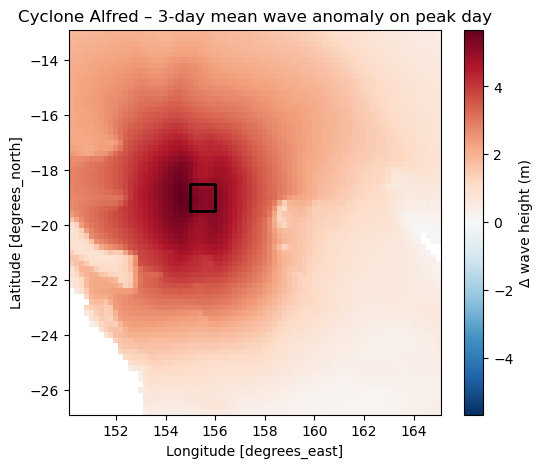

In [246]:
fig, ax = plt.subplots(figsize=(6, 5))
alfred_wave_ttest["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wave height (m)"},
)
draw_focus_box(ax, 155, 156, -19.5, -18.5)


plt.title("Cyclone Alfred – 3‑day mean wave anomaly on peak day")
plt.savefig("plots/new anomaly plots with box/alfred_wave_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()


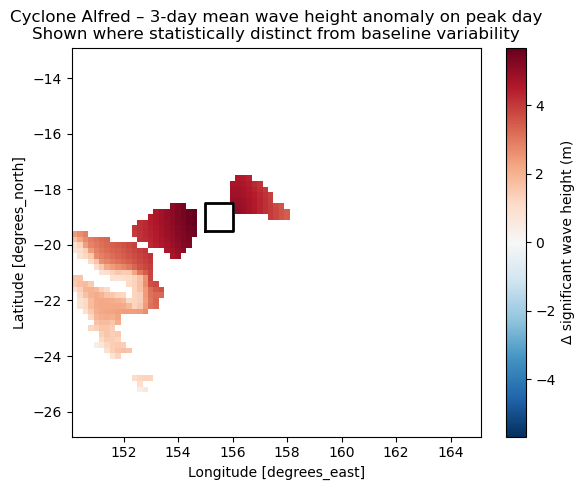

In [247]:
masked_alfred_wave = alfred_wave_ttest["anomaly"].where(
    alfred_wave_ttest["significant"]
)
fig, ax = plt.subplots(figsize=(6, 5))
masked_alfred_wave.plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ significant wave height (m)"},
)
draw_focus_box(ax, 155, 156, -19.5, -18.5)

plt.title(
    "Cyclone Alfred – 3‑day mean wave height anomaly on peak day\n"
    "Shown where statistically distinct from baseline variability"
)

plt.tight_layout()
plt.savefig("plots/new anomaly plots with box/alfred_wave_anomaly_significant.png", dpi=300, bbox_inches="tight")
plt.show()

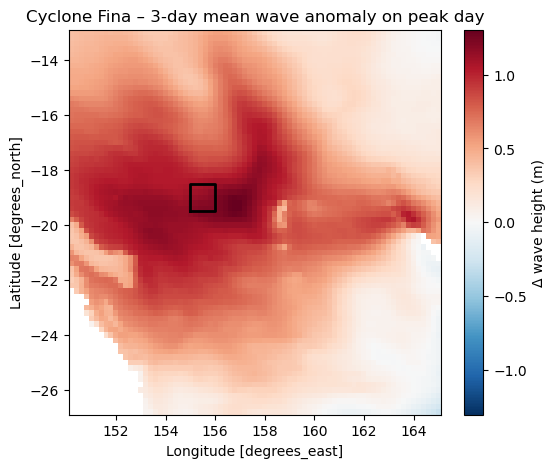

In [248]:
fig, ax = plt.subplots(figsize=(6, 5))
fina_wave_ttest["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ wave height (m)"},
)
draw_focus_box(ax, 155, 156, -19.5, -18.5)
plt.title("Cyclone Fina – 3‑day mean wave anomaly on peak day")
plt.savefig("plots/new anomaly plots with box/fina_wave_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()


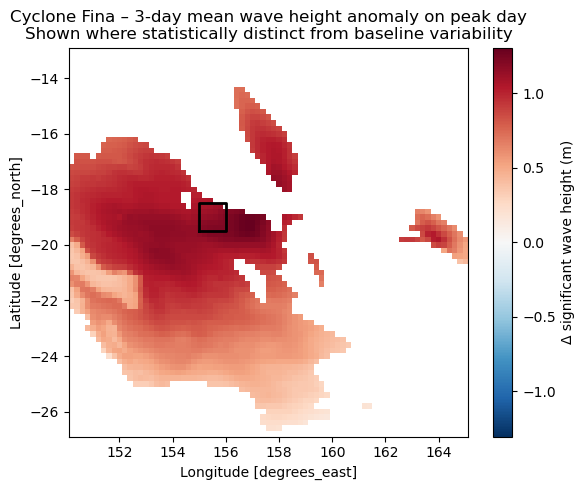

In [249]:
masked_fina_wave = fina_wave_ttest["anomaly"].where(
    fina_wave_ttest["significant"]
)
fig, ax = plt.subplots(figsize=(6, 5))
masked_fina_wave.plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "Δ significant wave height (m)"},
)
draw_focus_box(ax, 155, 156, -19.5, -18.5)
plt.title(
    "Cyclone Fina – 3‑day mean wave height anomaly on peak day\n"
    "Shown where statistically distinct from baseline variability"
)

plt.tight_layout()
plt.savefig("plots/new anomaly plots with box/fina_wave_anomaly_significant.png", dpi=300, bbox_inches="tight")
plt.show()

In [254]:
box_pvals = alfred_wave_ttest["p_value"].sel(
    longitude=slice(155, 156),
    latitude=slice(-19.5, -18.5),
)

print(
    "Mean p-value in box:",
    float(box_pvals.mean(skipna=True))
)
print(
    "Min p-value in box:",
    float(box_pvals.min(skipna=True))
)

Mean p-value in box: 0.053723976003984625
Min p-value in box: 0.050360632175635106


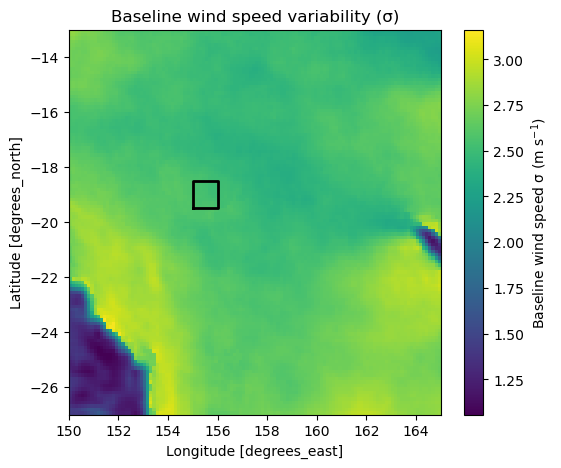

In [251]:
baseline_wind_std = xr.concat(
    [
        wind_speed_baseline_first,
        wind_speed_baseline_second,
        wind_speed_baseline_third,
    ],
    dim="time",
).std("time")

fig, ax = plt.subplots(figsize=(6, 5))
baseline_wind_std.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Baseline wind speed σ (m s$^{-1}$)"},
)

draw_focus_box(ax, 155, 156, -19.5, -18.5)

ax.set_title("Baseline wind speed variability (σ)")
plt.show()

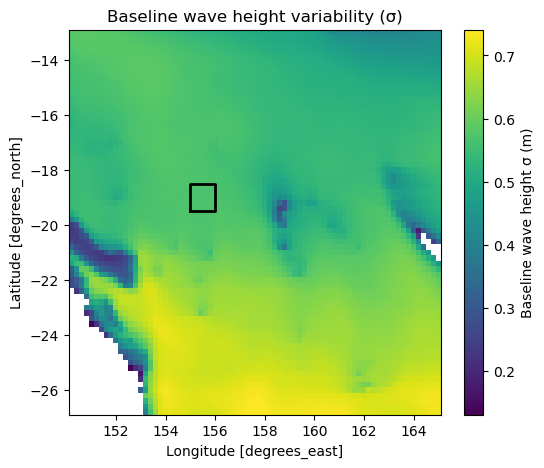

In [253]:
baseline_wave_std = xr.concat(
    [
        height_baseline_first,
        height_baseline_second,
        height_baseline_third,
    ],
    dim="time",
).std("time")

fig, ax = plt.subplots(figsize=(6, 5))
baseline_wave_std.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Baseline wave height σ (m)"},
)

draw_focus_box(ax, 155, 156, -19.5, -18.5)

ax.set_title("Baseline wave height variability (σ)")
plt.show()